# Notebook 01 — Pengumpulan dan Penyusunan Dataset
## Cleaning Data & Language Detection

**Deskripsi:**
Notebook ini mencakup tahap awal penyusunan dataset ulasan *attraction* di Bali,
meliputi:
1. Instalasi library dan import dependensi
2. Pembacaan dataset gabungan hasil scraping (TripAdvisor + Google Review)
3. Cleaning data awal (hapus kosong, duplikat, terlalu pendek)
4. Filtering awal berdasarkan label bahasa platform
5. Deteksi dan verifikasi bahasa otomatis menggunakan `langdetect`
6. Analisis mislabeling bahasa
7. Filtering berdasarkan hasil deteksi bahasa
8. Ekspor dataset bersih siap preprocessing

**Input:** `RAW_2026_03_01_Bali_Data_Tripadvisor+GoogleReview.xlsx`

**Output:** `Dataset_Bersih_Siap_Preprocessing.xlsx`

---

### Catatan Metodologis: Penyaringan Bahasa Dua Tahap

Penyaringan bahasa dilakukan dalam **dua tahap** yang saling melengkapi:

| Tahap | Dasar Penyaringan | Fungsi |
|-------|-------------------|--------|
| **Tahap 1** (Section 4) | Label bahasa bawaan platform | Menetapkan ruang lingkup awal penelitian pada tiga bahasa target |
| **Tahap 2** (Section 7) | Hasil deteksi otomatis `langdetect` | Memverifikasi dan mengoreksi bahasa yang sebenarnya digunakan |

Pendekatan dua tahap ini diperlukan karena label bahasa dari platform
**tidak selalu akurat** — banyak ulasan berbahasa Indonesia yang dilabeli
sebagai Bahasa Inggris oleh platform. Kolom `language_original` menyimpan
label bahasa asli platform, sedangkan kolom `language` berisi hasil deteksi
yang lebih akurat.

## Section 1 — Instalasi Library dan Import Dependensi

In [ ]:
!pip install langdetect pandas openpyxl matplotlib seaborn --quiet

print("✅ Semua library berhasil diinstall!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Semua library berhasil diinstall!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

# Agar hasil langdetect konsisten (reproducible)
DetectorFactory.seed = 42
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## Section 2 — Pembacaan Dataset Gabungan

Dataset gabungan hasil web scraping dari TripAdvisor dan Google Review
dibaca langsung dari file Excel. Kolom-kolom bawaan platform diseragamkan
menggunakan mapping nama kolom yang konsisten.

In [ ]:
import pandas as pd

# Baca dataset gabungan raw
FILE_INPUT = 'RAW_2026_03_01_Bali_Data_Tripadvisor+GoogleReview  (1).xlsx'

print(f"Membaca dataset: {FILE_INPUT}")
df = pd.read_excel(FILE_INPUT)
print(f"✅ Total baris awal: {len(df):,} baris")
print(f"   Kolom tersedia : {list(df.columns)}")

Membaca dataset: RAW_2026_03_01_Bali_Data_Tripadvisor+GoogleReview  (1).xlsx
✅ Total baris awal: 22,128 baris
   Kolom tersedia : ['place_name', 'place_id', 'user_id', 'rating', 'address', 'city', 'postal_code', 'latitude', 'longitude', 'language', 'review_text', 'review_date', 'source']


In [ ]:
# Mapping nama kolom ke format standar penelitian
df = df.rename(columns={
    'place_name'  : 'nama_tempat',
    'place_id'    : 'id_tempat',
    'address'     : 'alamat',
    'city'        : 'kabupaten',
    'review_text' : 'review',
    'source'      : 'sumber',
})

# Tambahkan kolom provinsi yang diseragamkan
df['provinsi'] = 'Bali'

# Pilih dan susun kolom yang dibutuhkan
KOLOM_PILIH = [
    'user_id', 'nama_tempat', 'id_tempat', 'rating',
    'kabupaten', 'provinsi', 'review', 'language', 'sumber'
]

# Hanya ambil kolom yang ada di dataset
kolom_ada = [c for c in KOLOM_PILIH if c in df.columns]
df = df[kolom_ada].copy()

print(f"✅ Kolom setelah mapping: {list(df.columns)}")
print(f"   Jumlah baris        : {len(df):,}")
df.head(3)

✅ Kolom setelah mapping: ['user_id', 'nama_tempat', 'id_tempat', 'rating', 'kabupaten', 'provinsi', 'review', 'language', 'sumber']
   Jumlah baris        : 22,128


,user_id,nama_tempat,id_tempat,rating,kabupaten,provinsi,review,language,sumber
0,106930109531231364164,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,"Рекомендую всем, фанатам, детям и женщинам буд...",en,Google Review
1,114125858000695161899,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,"Had a wonderful time at Kebon Vintage Cars, lo...",en,Google Review
2,116066024977580496440,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,NaN,en,Google Review


## Section 3 — Cleaning Data Awal

Tahap cleaning dilakukan untuk meningkatkan kualitas dataset sebelum
proses *language detection*. Langkah yang dilakukan:
- Hapus ulasan yang kosong (NaN / hanya spasi)
- Hapus data duplikat berdasarkan isi ulasan
- Hapus ulasan yang terlalu pendek (< 10 karakter)

In [ ]:
# Cleaning bertahap dengan tracking jumlah data
n_awal = len(df)
print(f"{'='*60}")
print(f"CLEANING DATA AWAL")
print(f"{'='*60}")
print(f"Dataset awal: {n_awal:,} baris\n")

# Langkah 1: Hapus review kosong (NaN / hanya spasi)
df['review'] = df['review'].replace(r'^\s*$', np.nan, regex=True)
df = df.dropna(subset=['review']).copy()
n1 = len(df)
print(f"Langkah 1 — Hapus review kosong/NaN    : -{n_awal - n1:>5,} baris → sisa {n1:,}")

# Langkah 2: Hapus duplikat berdasarkan isi ulasan
df = df.drop_duplicates(subset=['review']).copy()
n2 = len(df)
print(f"Langkah 2 — Hapus duplikat review      : -{n1 - n2:>5,} baris → sisa {n2:,}")

# Langkah 3: Hapus ulasan terlalu pendek (< 10 karakter)
df = df[df['review'].astype(str).str.len() >= 10].copy()
n3 = len(df)
print(f"Langkah 3 — Hapus review < 10 karakter : -{n2 - n3:>5,} baris → sisa {n3:,}")

df = df.reset_index(drop=True)

print(f"\n{'='*60}")
print(f"Total dihapus pada tahap cleaning : {n_awal - len(df):,} baris")
print(f"Dataset setelah cleaning          : {len(df):,} baris")

CLEANING DATA AWAL
Dataset awal: 22,128 baris

Langkah 1 — Hapus review kosong/NaN    : -6,462 baris → sisa 15,666
Langkah 2 — Hapus duplikat review      : -  457 baris → sisa 15,209
Langkah 3 — Hapus review < 10 karakter : -  246 baris → sisa 14,963

Total dihapus pada tahap cleaning : 7,165 baris
Dataset setelah cleaning          : 14,963 baris


## Section 4 — Filtering Awal Berdasarkan Label Bahasa Platform

Sebelum deteksi bahasa otomatis dijalankan, dataset terlebih dahulu disaring
berdasarkan **label bahasa bawaan platform** (TripAdvisor dan Google Review).

Tahap ini berfungsi sebagai **penetapan ruang lingkup awal** penelitian, yaitu
hanya mempertahankan ulasan yang menurut metadata platform ditulis dalam salah
satu dari tiga bahasa target. Ulasan berbahasa lain (misalnya Prancis, Jerman,
atau Belanda) dikeluarkan pada tahap ini karena berada di luar cakupan penelitian.

Kode bahasa yang diterima pada tahap ini mencakup variasi penulisan untuk
Bahasa Indonesia, yaitu `id` maupun `in`, karena kedua kode tersebut digunakan
secara bergantian oleh platform.

> **Catatan:** Label bahasa platform digunakan hanya sebagai penyaring awal,
> bukan sebagai penentu akhir. Verifikasi bahasa yang sebenarnya dilakukan pada
> Section 5 menggunakan deteksi otomatis, karena metadata platform tidak selalu
> akurat.

In [ ]:
# Filtering awal berdasarkan label bahasa platform
# Kode bahasa yang diterima:
#   'en'        → Bahasa Inggris
#   'id' / 'in' → Bahasa Indonesia (platform menggunakan kedua variasi kode)
#   'es'        → Bahasa Spanyol
BAHASA_PLATFORM = ['en', 'id', 'in', 'es']

n_sebelum_filter = len(df)

print(f"{'='*60}")
print(f"FILTERING AWAL BERDASARKAN LABEL BAHASA PLATFORM")
print(f"{'='*60}")

print(f"\n📊 Distribusi label bahasa platform (sebelum filter):")
print(df['language'].value_counts())

df = df[df['language'].isin(BAHASA_PLATFORM)].copy()
df = df.reset_index(drop=True)

print(f"\n{'='*60}")
print(f"Sebelum filter : {n_sebelum_filter:,} baris")
print(f"Sesudah filter : {len(df):,} baris")
print(f"Dihapus        : {n_sebelum_filter - len(df):,} baris "
      f"(label platform di luar en/id/in/es)")

print(f"\n📊 Distribusi label bahasa platform (sesudah filter):")
print(df['language'].value_counts())

FILTERING AWAL BERDASARKAN LABEL BAHASA PLATFORM

📊 Distribusi label bahasa platform (sebelum filter):
language
en      12304
fr        650
in        589
nl        279
de        273
it        270
ru        153
es        126
ja         82
pt         38
da         35
sv         32
tr         21
cs         20
th         17
pl         17
ko         12
hu         11
zhCN       11
no          8
zhTW        5
ar          4
vi          3
sk          1
iw          1
el          1
Name: count, dtype: int64

Sebelum filter : 14,963 baris
Sesudah filter : 13,019 baris
Dihapus        : 1,944 baris (label platform di luar en/id/in/es)

📊 Distribusi label bahasa platform (sesudah filter):
language
en    12304
in      589
es      126
Name: count, dtype: int64


## Section 5 — Deteksi dan Verifikasi Bahasa Otomatis

Proses language detection menggunakan pustaka `langdetect` untuk
memverifikasi bahasa yang sebenarnya digunakan dalam teks ulasan,
karena metadata bahasa dari platform tidak selalu akurat.

Bahasa target penelitian: **Bahasa Indonesia (id)**, **Bahasa Inggris (en)**,
dan **Bahasa Spanyol (es)**.

In [ ]:
# Fungsi deteksi bahasa
def detect_language(text):
    """
    Mendeteksi bahasa dari teks menggunakan langdetect.
    Mengembalikan kode bahasa (en, id, es, dll) atau 'unknown' jika gagal.
    """
    try:
        if not isinstance(text, str) or len(text.strip()) < 10:
            return 'unknown'
        return detect(text)
    except LangDetectException:
        return 'unknown'


def map_to_target_lang(lang_code):
    """Pemetaan kode bahasa ke tiga bahasa target penelitian atau 'other'."""
    if lang_code == 'en':
        return 'en'
    elif lang_code in ['id', 'in']:
        return 'id'
    elif lang_code == 'es':
        return 'es'
    else:
        return 'other'

In [ ]:
# Jalankan deteksi bahasa dengan progress tracking
print("=" * 55)
print("🔍 DETEKSI BAHASA OTOMATIS")
print("=" * 55)
print("⏳ Proses ini mungkin memakan waktu 3–5 menit...\n")

total = len(df)
detected_langs = []
batch_size = 500

for i in range(0, total, batch_size):
    batch = df['review'].iloc[i:i+batch_size]
    batch_result = batch.apply(detect_language).tolist()
    detected_langs.extend(batch_result)
    progress = min(i + batch_size, total)
    print(f"   Progress: {progress:,}/{total:,} ({progress/total*100:.1f}%)", end='\r')

df['language_detected'] = detected_langs
df['language_detected_mapped'] = df['language_detected'].apply(map_to_target_lang)

print(f"\n\n✅ Deteksi bahasa selesai!")
print(f"\n📊 Hasil deteksi bahasa (langdetect):")
print(df['language_detected_mapped'].value_counts())

🔍 DETEKSI BAHASA OTOMATIS
⏳ Proses ini mungkin memakan waktu 3–5 menit...

   Progress: 13,019/13,019 (100.0%)

✅ Deteksi bahasa selesai!

📊 Hasil deteksi bahasa (langdetect):
language_detected_mapped
en       6982
id       3547
other    2240
es        250
Name: count, dtype: int64


## Section 6 — Analisis Mislabeling Bahasa

Perbandingan antara label bahasa bawaan platform dengan hasil deteksi
otomatis untuk mengidentifikasi ulasan yang bahasanya tidak sesuai
dengan metadata platform.

In [ ]:
# Crosstab: label asli vs hasil deteksi
print("=" * 55)
print("⚠️  ANALISIS MISLABELING BAHASA")
print("=" * 55)

# Simpan language asli dari platform sebelum diupdate
df['language_original'] = df['language'].copy()

print("\n📊 Crosstab: Label Bahasa Platform vs Deteksi Langdetect:")
crosstab = pd.crosstab(
    df['language_original'],
    df['language_detected_mapped'],
    margins=True,
    margins_name='Total'
)
print(crosstab)

mislabeled = df[df['language_original'] != df['language_detected_mapped']]
print(f"\n⚠️  Total baris mismatch (label platform ≠ deteksi): {len(mislabeled):,}")
print(f"   Persentase mismatch: {len(mislabeled)/len(df)*100:.2f}%")

print(f"\n📋 Contoh 5 ulasan mislabeled:")
print("-" * 80)
for idx, row in mislabeled[['language_original','language_detected_mapped','review']].head(5).iterrows():
    print(f"Label platform: '{row['language_original']}' | Terdeteksi: '{row['language_detected_mapped']}'")
    print(f"Review: {str(row['review'])[:120]}...")
    print("-" * 80)

⚠️  ANALISIS MISLABELING BAHASA

📊 Crosstab: Label Bahasa Platform vs Deteksi Langdetect:
language_detected_mapped    en   es    id  other  Total
language_original                                      
en                        6857  153  3056   2238  12304
es                          29   97     0      0    126
in                          96    0   491      2    589
Total                     6982  250  3547   2240  13019

⚠️  Total baris mismatch (label platform ≠ deteksi): 6,065
   Persentase mismatch: 46.59%

📋 Contoh 5 ulasan mislabeled:
--------------------------------------------------------------------------------
Label platform: 'en' | Terdeteksi: 'other'
Review: Рекомендую всем, фанатам, детям и женщинам будет интересно! Внутри кафе и магазинчик, машин 150-200....
--------------------------------------------------------------------------------
Label platform: 'en' | Terdeteksi: 'id'
Review: Menemukan tempat ini karena tamu ingin mengunjungi beberapa musium.<br>Ini adalah salah

## Section 7 — Filtering Berdasarkan Hasil Deteksi Bahasa

Dataset disaring hanya pada tiga bahasa target penelitian (id, en, es)
berdasarkan hasil deteksi otomatis yang lebih akurat. Kolom `language`
diperbarui menggunakan hasil deteksi, sedangkan kolom `language_original`
menyimpan label bahasa asli dari platform.

In [ ]:
# Update kolom language dengan hasil deteksi yang lebih akurat
# Catatan: kolom 'language_original' sudah disimpan pada Section 6
#          sebelum kolom 'language' diperbarui.
df['language'] = df['language_detected_mapped']

# Filter hanya bahasa target berdasarkan HASIL DETEKSI
TARGET_LANGS = ['en', 'id', 'es']
n_sebelum = len(df)

df = df[df['language'].isin(TARGET_LANGS)].copy()
n_sesudah = len(df)

# Hapus kolom bantu deteksi yang tidak dibutuhkan lagi
df = df.drop(columns=['language_detected', 'language_detected_mapped'], errors='ignore')
df = df.reset_index(drop=True)

print("=" * 60)
print("FILTERING BERDASARKAN HASIL DETEKSI BAHASA")
print("=" * 60)
print(f"Sebelum filtering : {n_sebelum:,} baris")
print(f"Sesudah filtering : {n_sesudah:,} baris")
print(f"Dihapus           : {n_sebelum - n_sesudah:,} baris")
print(f"   (terdeteksi sebagai bahasa selain en/id/es meskipun")
print(f"    label platformnya termasuk bahasa target)")

print(f"\n📊 Distribusi bahasa final (hasil deteksi):")
for lang, count in df['language'].value_counts().items():
    print(f"   {lang:<5}: {count:>6,} ({count/len(df)*100:>5.2f}%)")

print(f"\n📊 Distribusi label platform asli (language_original):")
for lang, count in df['language_original'].value_counts().items():
    print(f"   {lang:<5}: {count:>6,} ({count/len(df)*100:>5.2f}%)")

print(f"\n📊 Distribusi rating:")
print(df['rating'].value_counts().sort_index())

FILTERING BERDASARKAN HASIL DETEKSI BAHASA
Sebelum filtering : 13,019 baris
Sesudah filtering : 10,779 baris
Dihapus           : 2,240 baris
   (terdeteksi sebagai bahasa selain en/id/es meskipun
    label platformnya termasuk bahasa target)

📊 Distribusi bahasa final (hasil deteksi):
   en   :  6,982 (64.77%)
   id   :  3,547 (32.91%)
   es   :    250 ( 2.32%)

📊 Distribusi label platform asli (language_original):
   en   : 10,066 (93.39%)
   in   :    587 ( 5.45%)
   es   :    126 ( 1.17%)

📊 Distribusi rating:
rating
1     943
2     396
3     727
4    1749
5    6964
Name: count, dtype: int64


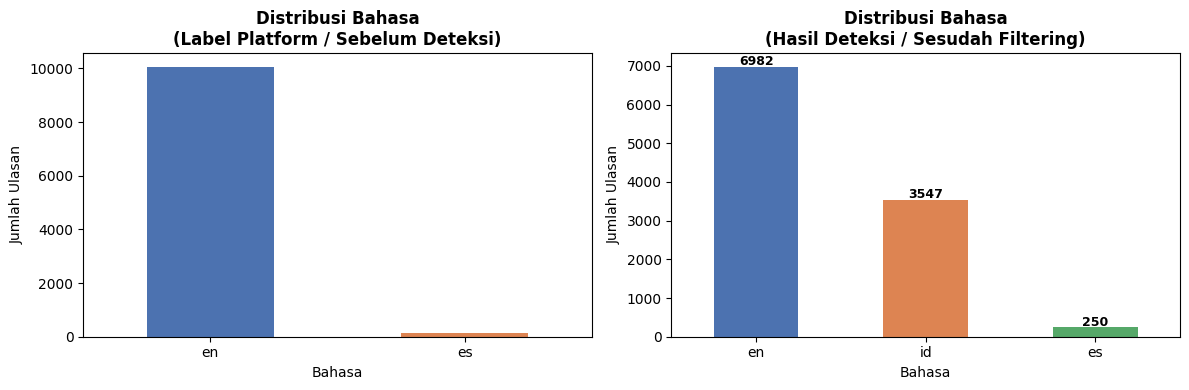

✅ Visualisasi disimpan: 01_Distribusi_Bahasa_Sebelum_Sesudah.png


In [ ]:
# Visualisasi distribusi bahasa sebelum vs sesudah
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sebelum (berdasarkan label platform)
before_counts = df['language_original'].value_counts()
before_counts[before_counts.index.isin(TARGET_LANGS + ['other'])].plot(
    kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868','#c44e52'])
axes[0].set_title('Distribusi Bahasa\n(Label Platform / Sebelum Deteksi)', fontweight='bold')
axes[0].set_xlabel('Bahasa')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].tick_params(axis='x', rotation=0)

# Sesudah (berdasarkan hasil deteksi)
after_counts = df['language'].value_counts()
after_counts.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452','#55A868'])
axes[1].set_title('Distribusi Bahasa\n(Hasil Deteksi / Sesudah Filtering)', fontweight='bold')
axes[1].set_xlabel('Bahasa')
axes[1].set_ylabel('Jumlah Ulasan')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('01_Distribusi_Bahasa_Sebelum_Sesudah.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi disimpan: 01_Distribusi_Bahasa_Sebelum_Sesudah.png")

## Section 8 — Ekspor Dataset Bersih

Dataset yang telah melalui proses cleaning dan language detection
diekspor sebagai file Excel untuk digunakan pada Notebook 02
(Preprocessing, Proxy Label, dan Pembagian Dataset).

Struktur kolom output mencakup semua informasi yang dibutuhkan
pada tahap selanjutnya, termasuk `language_original` sebagai
jejak bahasa bawaan platform sebelum normalisasi.

In [ ]:
# Susun kolom output
KOLOM_OUTPUT = [
    'user_id', 'nama_tempat', 'id_tempat', 'rating',
    'kabupaten', 'provinsi', 'review',
    'language', 'language_original', 'sumber'
]

kolom_output_ada = [c for c in KOLOM_OUTPUT if c in df.columns]
df_output = df[kolom_output_ada].copy()

FILE_OUTPUT = 'Dataset_Bersih_Siap_Preprocessing.xlsx'
df_output.to_excel(FILE_OUTPUT, index=False)

print("=" * 55)
print("🎉 NOTEBOOK 01 SELESAI!")
print("=" * 55)
print(f"\n📁 Output: '{FILE_OUTPUT}'")
print(f"\n📊 RINGKASAN AKHIR:")
print(f"┌──────────────────────────────────────────────────┐")
print(f"│  Dataset awal (raw)           : {n_awal:>7,} baris    │")
print(f"│  Dataset bersih (output)      : {len(df_output):>7,} baris    │")
print(f"│  Total baris dihapus          : {n_awal - len(df_output):>7,} baris    │")
print(f"├──────────────────────────────────────────────────┤")
print(f"│  Distribusi bahasa:                              │")
for lang, count in df_output['language'].value_counts().items():
    print(f"│    {lang:<8}: {count:>6,} ulasan{' '*20}│")
print(f"└──────────────────────────────────────────────────┘")
print(f"\n➡️  Lanjutkan ke Notebook 02 untuk preprocessing,")
print(f"   pembentukan proxy label, dan pembagian dataset.")

🎉 NOTEBOOK 01 SELESAI!

📁 Output: 'Dataset_Bersih_Siap_Preprocessing.xlsx'

📊 RINGKASAN AKHIR:
┌──────────────────────────────────────────────────┐
│  Dataset awal (raw)           :  22,128 baris    │
│  Dataset bersih (output)      :  10,779 baris    │
│  Total baris dihapus          :  11,349 baris    │
├──────────────────────────────────────────────────┤
│  Distribusi bahasa:                              │
│    en      :  6,982 ulasan                    │
│    id      :  3,547 ulasan                    │
│    es      :    250 ulasan                    │
└──────────────────────────────────────────────────┘

➡️  Lanjutkan ke Notebook 02 untuk preprocessing,
   pembentukan proxy label, dan pembagian dataset.
